In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import folium
from pandasql import sqldf
# 设置中文字体（黑体）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 1. 数据加载与初步探索
df = pd.read_csv('vgsales.csv')
print("数据大小:", df.shape)
print("\n前3行数据示例:\n", df.head(3))
print("\n缺失值统计:\n", df.isnull().sum())
print("\n数据统计：\n", df.describe())  # 数据出现2020年，与实际数据集创建时间不符。
print(df.value_counts('Year', ascending=True))  # 查看各年份出现次数

In [ ]:
# 2. 数据清洗
# 处理缺失值：删除年份缺失的记录
df_clean = df.dropna(subset=['Year'])
# 2017年和2020年数据过少，选择删除处理。
df_clean.drop(
    df_clean[(df_clean["Year"] == 2017) | (df_clean["Year"] == 2020)].index,
    inplace=True
)
# 确保年份为整数
df['Year'] = df['Year'].astype(int)

In [ ]:
# 3. 核心分析
# 分析1：全球最畅销的10款游戏
top_games = df_clean.sort_values(by='Global_Sales', ascending=False).head(10)
print("\n全球最畅销的10款游戏:\n", top_games[['Name', 'Platform', 'Year', 'Global_Sales']])

In [ ]:
# 分析2：各游戏类型的全球销售额占比
genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.values, y=genre_sales.index, palette='viridis')
plt.title('各游戏类型的全球销售额排名')
plt.xlabel('全球销售额（百万美元）')
plt.ylabel('游戏类型')
plt.show()

In [ ]:
# 分析3：不同平台的游戏发行量趋势（SQL）（主流平台：PS2, X360, PS3, PC, Wii）

sql = """
SELECT 
    Year,                  
    Platform,              
    COUNT(Name) AS Game_Count  
FROM 
    df_clean                
WHERE 
    Platform IN ('PS2', 'X360', 'PS3', 'PC', 'Wii')  
GROUP BY 
    Year, Platform         
ORDER BY 
    Year ASC, Platform;    
"""
result = sqldf(sql,locals())
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y=result['Game_Count'], hue='Platform', data=result, marker='o')
plt.title('主流平台游戏发行量趋势')
plt.xlabel('年份')
plt.ylabel('发行游戏数量')
plt.grid(True)
plt.show()

In [ ]:
# 分析4：各地区市场份额对比（北美、欧洲、日本）
region_sales = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
labels = ['北美', '欧洲', '日本', '其他地区']
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('各地区销售额占比')
plt.show()

In [ ]:
# 分析5：发行商市场份额TOP10
publisher_sales = df_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=publisher_sales.values, y=publisher_sales.index, palette='rocket')
plt.title('全球TOP10发行商市场份额')
plt.xlabel('全球销售额（百万美元）')
plt.ylabel('发行商')
plt.show()

In [ ]:
# 4. 业务建议总结
print("""
**关键结论与建议**：
1. **游戏类型**：动作类（Action）和体育类（Sports）销售额占比最高（合计超30%），建议加大这两类游戏的研发投入；
2. **地区市场**：北美市场占比48.7%；日本市场RPG类占比35%，建议研究本地化发行策略；
3. **发行商**：任天堂（Nintendo）市场份额遥遥领先（超17%），可研究其经典IP运营模式。
""")

In [32]:
# 2. 数据清洗
# 确保年份为整数
df['Year'] = df['Year'].astype(int)
# 处理缺失值：删除年份缺失的记录
df_clean = df.dropna(subset=['Year'])
# 2017年和2020年数据过少，选择删除处理。
df_clean.drop(
    df_clean[(df_clean["Year"] == 2017) | (df_clean["Year"] == 2020)].index,
    inplace=True
)

        Rank                                              Name Platform  \
0          1                                        Wii Sports      Wii   
1          2                                 Super Mario Bros.      NES   
2          3                                    Mario Kart Wii      Wii   
3          4                                 Wii Sports Resort      Wii   
4          5                          Pokemon Red/Pokemon Blue       GB   
...      ...                                               ...      ...   
16593  16596                Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                     Men in Black II: Alien Escape       GC   
16595  16598  SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                        Know How 2       DS   
16597  16600                                  Spirits & Spells      GBA   

         Year         Genre   Publisher  NA_Sales  EU_Sales  JP_Sales  \
0      2006.0        Sport

In [33]:
# 3. 核心分析
# 分析1：全球最畅销的10款游戏
top_games = df_clean.sort_values(by='Global_Sales', ascending=False).head(10)
print("\n全球最畅销的10款游戏:\n", top_games[['Name', 'Platform', 'Year', 'Global_Sales']])


全球最畅销的10款游戏:
                         Name Platform    Year  Global_Sales
0                 Wii Sports      Wii  2006.0         82.74
1          Super Mario Bros.      NES  1985.0         40.24
2             Mario Kart Wii      Wii  2008.0         35.82
3          Wii Sports Resort      Wii  2009.0         33.00
4   Pokemon Red/Pokemon Blue       GB  1996.0         31.37
5                     Tetris       GB  1989.0         30.26
6      New Super Mario Bros.       DS  2006.0         30.01
7                   Wii Play      Wii  2006.0         29.02
8  New Super Mario Bros. Wii      Wii  2009.0         28.62
9                  Duck Hunt      NES  1984.0         28.31


C:\Users\dxh\AppData\Local\Temp\ipykernel_18088\1040375115.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_sales.values, y=genre_sales.index, palette='viridis')


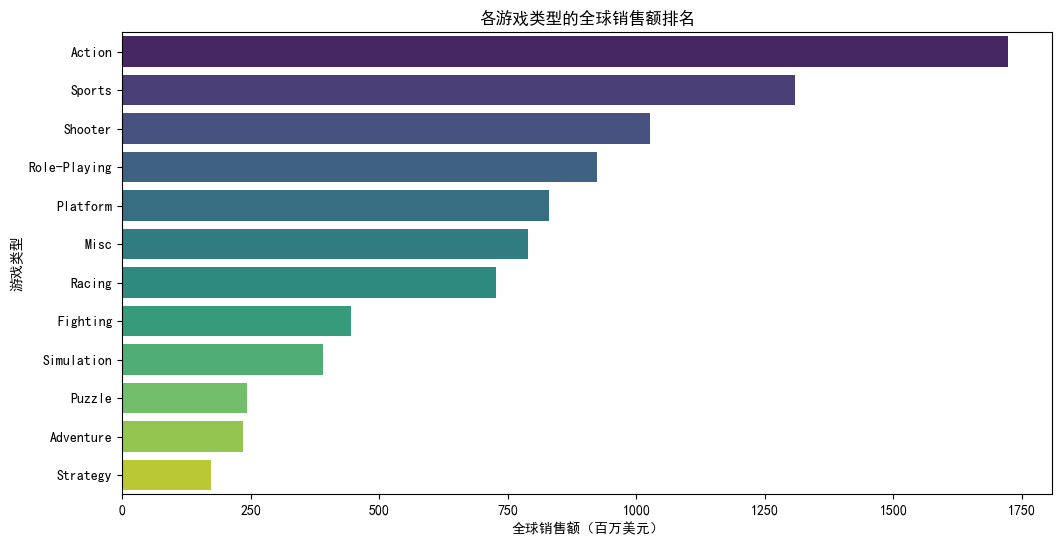

In [34]:
# 分析2：各游戏类型的全球销售额占比
genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=genre_sales.values, y=genre_sales.index, palette='viridis')
plt.title('各游戏类型的全球销售额排名')
plt.xlabel('全球销售额（百万美元）')
plt.ylabel('游戏类型')
plt.show()

      Year Platform  Game_Count
0   1985.0       PC           1
1   1988.0       PC           1
2   1992.0       PC           5
3   1994.0       PC           6
4   1995.0       PC           2
..     ...      ...         ...
66  2015.0      Wii           4
67  2015.0     X360          40
68  2016.0       PC          38
69  2016.0      PS3          32
70  2016.0     X360           8

[71 rows x 3 columns]


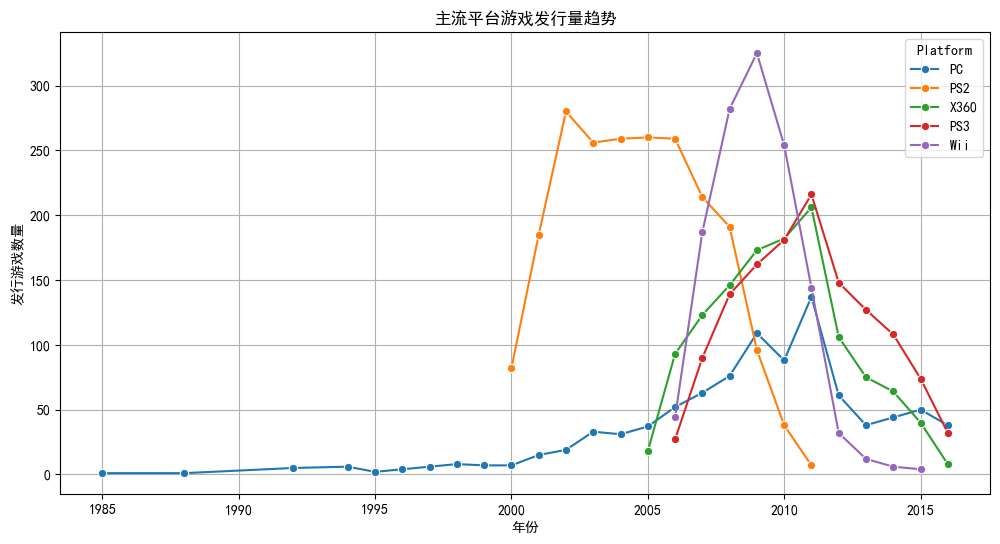

In [38]:
# 分析3：不同平台的游戏发行量趋势（SQL）（主流平台：PS2, X360, PS3, PC, Wii）

sql = """
SELECT 
    Year,                  
    Platform,              
    COUNT(Name) AS Game_Count  
FROM 
    df_clean                
WHERE 
    Platform IN ('PS2', 'X360', 'PS3', 'PC', 'Wii')  
GROUP BY 
    Year, Platform         
ORDER BY 
    Year ASC, Platform;    
"""
result = sqldf(sql,locals())
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y=result['Game_Count'], hue='Platform', data=result, marker='o')
plt.title('主流平台游戏发行量趋势')
plt.xlabel('年份')
plt.ylabel('发行游戏数量')
plt.grid(True)
plt.show()

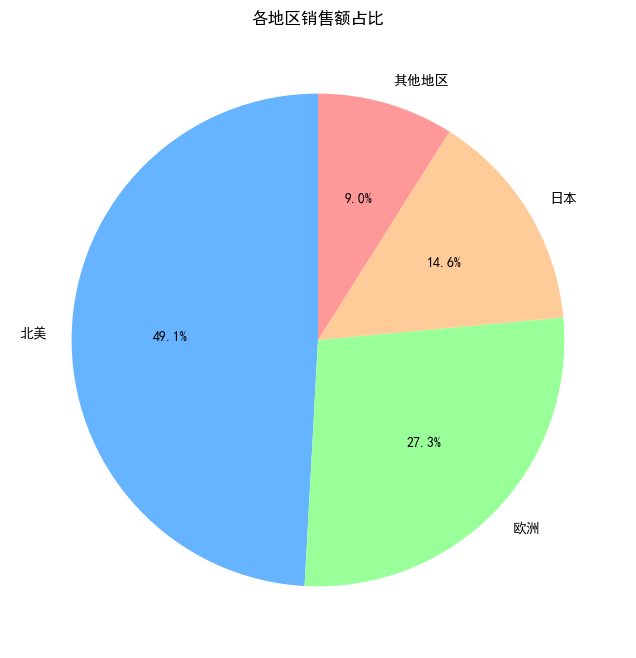

In [39]:
# 分析4：各地区市场份额对比（北美、欧洲、日本）
region_sales = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
labels = ['北美', '欧洲', '日本', '其他地区']
colors = ['#66b3ff', '#99ff99', '#ffcc99', '#ff9999']

plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('各地区销售额占比')
plt.show()

C:\Users\dxh\AppData\Local\Temp\ipykernel_18088\4053405149.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=publisher_sales.values, y=publisher_sales.index, palette='rocket')


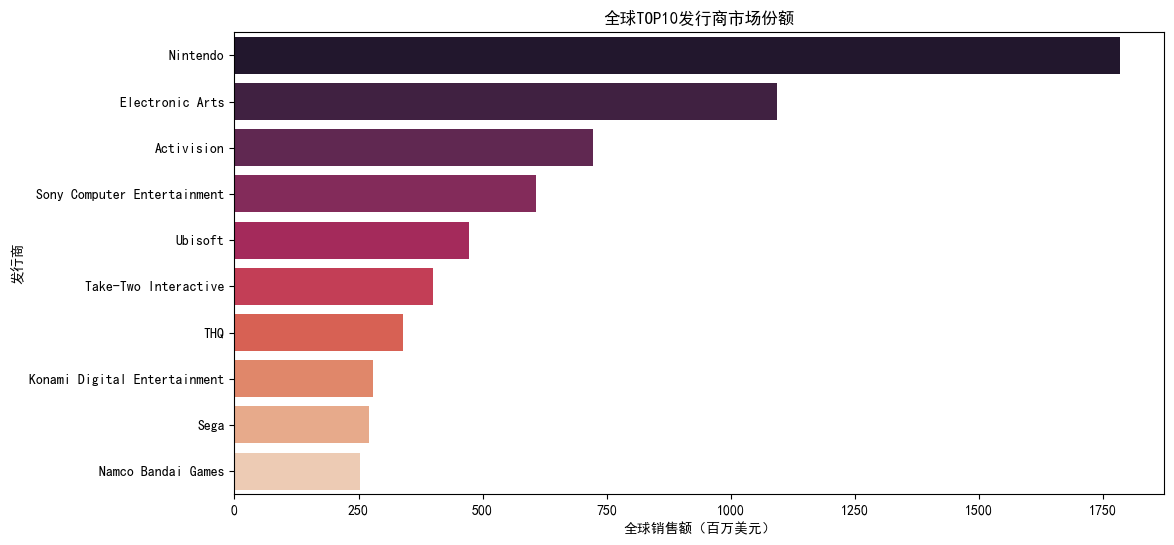

In [40]:
# 分析5：发行商市场份额TOP10
publisher_sales = df_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=publisher_sales.values, y=publisher_sales.index, palette='rocket')
plt.title('全球TOP10发行商市场份额')
plt.xlabel('全球销售额（百万美元）')
plt.ylabel('发行商')
plt.show()

In [ ]:
# 4. 业务建议总结
print("""
**关键结论与建议**：
1. **游戏类型**：动作类（Action）和体育类（Sports）销售额占比最高（合计超30%），建议加大这两类游戏的研发投入；
2. **地区市场**：北美市场占比48.7%；日本市场RPG类占比35%，建议研究本地化发行策略；
3. **发行商**：任天堂（Nintendo）市场份额遥遥领先（超17%），可研究其经典IP运营模式。
""")